## Anexo — Scouting: percentiles y similaridad entre jugadores

Basado en el anexo "Player Scouting" del temario: grids de percentiles y
búsqueda de jugadores similares.

Usa el dataset real de `07_fbref_rendimiento_jugador.ipynb`
(`data/raw/fbref_big5_player_standard_2025.csv`), más dos métricas
defensivas reales (`tackles_won`, `interceptions`) de
`data/raw/fbref_big5_player_defense_partial_2025.csv`.

Limitación real y ya cerrada: FBref no entrega al público gratuito el resto
de las columnas detalladas de passing/defense (probado hasta con exportación
manual desde navegador humano) — de ~37 columnas detalladas entre ambas
tablas, solo estas 2 defensivas están pobladas. El perfil de percentiles de
aquí sigue siendo mayormente ofensivo, con una single señal defensiva.

In [10]:
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 40)

df = pd.read_csv("../data/raw/fbref_big5_player_standard_2025.csv")
defensa = pd.read_csv("../data/raw/fbref_big5_player_defense_partial_2025.csv")

df = df.merge(
    defensa[["player", "team", "tackles_won", "interceptions"]],
    on=["player", "team"], how="left",
)

# Filtramos a jugadores con minutos suficientes para que los percentiles
# no se distorsionen por muestras chiquitas (ver 07 para la explicación).
regulares = df[df["minutes_90s"] >= 10].copy()

regulares["tackles_won_per90"] = regulares["tackles_won"] / regulares["minutes_90s"]
regulares["interceptions_per90"] = regulares["interceptions"] / regulares["minutes_90s"]

# `position` puede traer varias posiciones (ej. "MF,FW") — nos quedamos con
# la primera como posición principal para agrupar.
regulares["posicion_principal"] = regulares["position"].str.split(",").str[0]

print(f"{len(regulares)} jugadores regulares")
print(f"con dato defensivo: {regulares['tackles_won'].notna().sum()}")
regulares["posicion_principal"].value_counts()

1573 jugadores regulares
con dato defensivo: 1573


posicion_principal
MF    706
DF    539
FW    208
GK    120
Name: count, dtype: int64

## Grid de percentiles por posición

Los percentiles se calculan **dentro de cada posición principal** — un
delantero se compara contra otros delanteros, no contra defensas centrales.

In [11]:
metricas = [
    "goals_per90", "assists_per90", "goals_assists_per90", "goals_pens_per90",
    "tackles_won_per90", "interceptions_per90",
]

percentiles = regulares.groupby("posicion_principal")[metricas].rank(pct=True) * 100
percentiles = percentiles.round(0).astype(int)
percentiles.columns = [f"pctl_{c}" for c in percentiles.columns]

regulares = pd.concat([regulares, percentiles], axis=1)

cols_mostrar = ["player", "team", "comp_level", "posicion_principal"] + list(percentiles.columns)
delanteros = regulares[regulares["posicion_principal"] == "FW"].sort_values("pctl_goals_assists_per90", ascending=False)
delanteros[cols_mostrar].head(10).style.background_gradient(cmap="RdYlGn", subset=list(percentiles.columns), vmin=0, vmax=100)

,player,team,comp_level,posicion_principal,pctl_goals_per90,pctl_assists_per90,pctl_goals_assists_per90,pctl_goals_pens_per90,pctl_tackles_won_per90,pctl_interceptions_per90
695,Ousmane Dembélé,PSG,fr Ligue 1,FW,99,92,100,99,23,93
1631,Omar Marmoush,Frankfurt,de Bundesliga,FW,97,100,100,97,69,58
2611,Ferran Torres,Barcelona,es La Liga,FW,94,99,99,97,46,75
1317,Harry Kane,Bayern Munich,de Bundesliga,FW,99,95,99,91,39,28
2201,Mateo Retegui,Atalanta,it Serie A,FW,97,90,98,96,39,23
2538,Alexander Sørloth,Atlético Madrid,es La Liga,FW,100,45,98,100,26,10
1042,Amine Gouiri,Marseille,fr Ligue 1,FW,95,85,97,98,50,18
2370,Patrik Schick,Leverkusen,de Bundesliga,FW,100,6,97,100,24,48
2171,Gonçalo Ramos,PSG,fr Ligue 1,FW,94,83,96,93,59,2
328,Mika Biereth,Monaco,fr Ligue 1,FW,98,60,96,99,37,65


## Foco en un jugador específico

En vez de solo ver el top-10, aquí resaltamos a un jugador puntual dentro de
su grupo de posición — mostrando una "ventana" de jugadores alrededor de su
puesto en el ranking, con su fila marcada.

In [12]:
jugador_foco = "Kylian Mbappé"  # cambia aquí el nombre del jugador que quieras resaltar

posicion_foco = regulares.loc[regulares["player"] == jugador_foco, "posicion_principal"].iloc[0]
grupo = regulares[regulares["posicion_principal"] == posicion_foco].sort_values(
    "pctl_goals_assists_per90", ascending=False
).reset_index(drop=True)

idx_foco = grupo.index[grupo["player"] == jugador_foco][0]
ventana = grupo.iloc[max(0, idx_foco - 5): idx_foco + 6]

def resaltar_jugador(fila):
    es_foco = fila["player"] == jugador_foco
    return ["border: 3px solid black" if es_foco else "" for _ in fila]

ventana[cols_mostrar].style.background_gradient(
    cmap="RdYlGn", subset=list(percentiles.columns), vmin=0, vmax=100
).apply(resaltar_jugador, axis=1)

,player,team,comp_level,posicion_principal,pctl_goals_per90,pctl_assists_per90,pctl_goals_assists_per90,pctl_goals_pens_per90,pctl_tackles_won_per90,pctl_interceptions_per90
7,Patrik Schick,Leverkusen,de Bundesliga,FW,100,6,97,100,24,48
8,Gonçalo Ramos,PSG,fr Ligue 1,FW,94,83,96,93,59,2
9,Mika Biereth,Monaco,fr Ligue 1,FW,98,60,96,99,37,65
10,Georges Mikautadze,Lyon,fr Ligue 1,FW,89,97,95,83,38,58
11,Cristhian Stuani,Girona,es La Liga,FW,96,67,95,92,71,98
12,Kylian Mbappé,Real Madrid,es La Liga,FW,98,35,94,95,8,4
13,Bradley Barcola,PSG,fr Ligue 1,FW,84,98,94,88,82,99
14,Robert Lewandowski,Barcelona,es La Liga,FW,96,24,93,97,10,26
15,Ayoze Pérez,Villarreal,es La Liga,FW,95,35,93,98,75,71
16,Alexander Isak,Newcastle,eng Premier League,FW,92,76,92,90,9,20


## Perfil de un jugador (pizza chart)

Percentiles de un jugador puntual frente a su misma posición, en formato
radar/pizza como en el Módulo 9 del temario.

Text(0.5, 1.0, 'Kylian Mbappé — percentiles vs. FW de las 5 grandes ligas 2024-25')

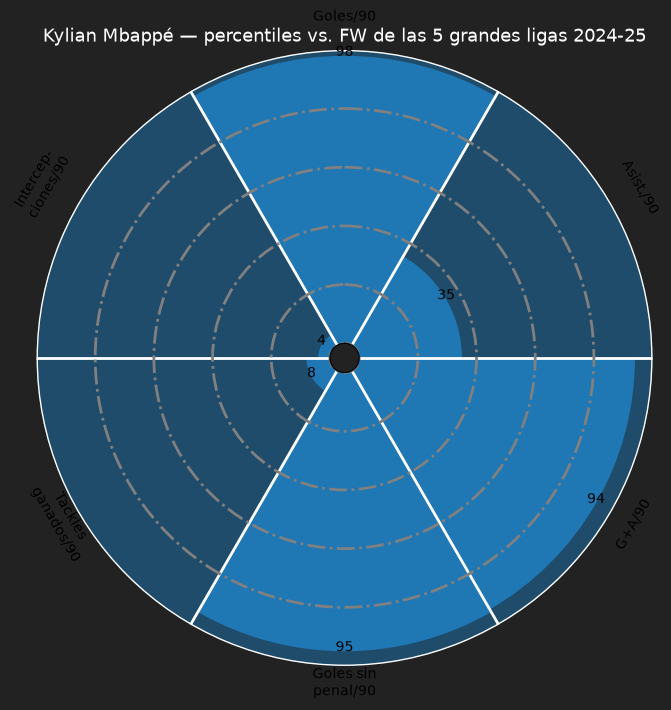

In [13]:
from mplsoccer import PyPizza

fila = regulares[regulares["player"] == jugador_foco].iloc[0]

valores = [int(fila[f"pctl_{m}"]) for m in metricas]
etiquetas = [
    "Goles/90", "Asist./90", "G+A/90", "Goles sin\npenal/90",
    "Tackles\nganados/90", "Intercep-\nciones/90",
]

baker = PyPizza(
    params=etiquetas,
    background_color="#222222",
    straight_line_color="#FFFFFF",
    last_circle_color="#FFFFFF",
    other_circle_ls="-.",
)
fig, ax = baker.make_pizza(
    valores,
    figsize=(8, 8),
    color_blank_space="same",
    param_location=110,
)
ax.set_title(
    f"{jugador_foco} — percentiles vs. {fila['posicion_principal']} de las 5 grandes ligas 2024-25",
    color="white", fontsize=13,
)

## Similaridad entre jugadores

Normalizamos las métricas por-90 (z-score) y calculamos similaridad coseno
**dentro de la misma posición principal** — buscar "similares" a un delantero
entre porteros no tiene sentido.

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

def jugadores_similares(nombre, top_n=5):
    fila = regulares[regulares["player"] == nombre].iloc[0]
    grupo = regulares[regulares["posicion_principal"] == fila["posicion_principal"]].reset_index(drop=True)

    X = StandardScaler().fit_transform(grupo[metricas])
    sim_matrix = cosine_similarity(X)
    sim_df = pd.DataFrame(sim_matrix, index=grupo["player"], columns=grupo["player"])

    similares = sim_df[nombre].drop(nombre).sort_values(ascending=False).head(top_n)
    resultado = grupo.set_index("player").loc[similares.index, ["team", "comp_level"] + metricas]
    resultado.insert(0, "similaridad", similares.round(3))
    return resultado

jugadores_similares("Kylian Mbappé")

,similaridad,team,comp_level,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,tackles_won_per90,interceptions_per90
player,,,,,,,,,
Jonathan Burkardt,0.986,Mainz 05,de Bundesliga,0.77,0.09,0.85,0.68,0.299145,0.042735
Erling Haaland,0.984,Manchester City,eng Premier League,0.72,0.10,0.82,0.62,0.197368,0.164474
Robert Lewandowski,0.983,Barcelona,es La Liga,0.91,0.07,0.98,0.81,0.168919,0.135135
Serhou Guirassy,0.981,Dortmund,de Bundesliga,0.73,0.14,0.87,0.62,0.207612,0.173010
Myron Boadu,0.979,Bochum,de Bundesliga,0.78,0.09,0.86,0.69,0.086207,0.086207


In [15]:
jugadores_similares("Harry Kane")

,similaridad,team,comp_level,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,tackles_won_per90,interceptions_per90
player,,,,,,,,,
Mateo Retegui,0.981,Atalanta,it Serie A,0.94,0.30,1.25,0.79,0.377358,0.113208
Gonçalo Ramos,0.946,PSG,fr Ligue 1,0.84,0.25,1.10,0.68,0.508475,0.000000
Georges Mikautadze,0.944,Lyon,fr Ligue 1,0.68,0.37,1.06,0.50,0.372671,0.248447
Omar Marmoush,0.941,Frankfurt,de Bundesliga,0.93,0.56,1.49,0.81,0.559006,0.248447
Amine Gouiri,0.935,Marseille,fr Ligue 1,0.86,0.26,1.12,0.86,0.431034,0.086207


## Exportar para Tableau (Fase 6)

Tabla lista para importar directo en Tableau Public: un jugador por fila, con
sus métricas per-90 y el percentil ya calculado (0-100) dentro de su posición
principal. Así en Tableau solo hay que arrastrar campos — no hace falta
recalcular nada.

In [16]:
cols_exportar = (
    ["player", "team", "comp_level", "posicion_principal", "age", "minutes_90s"]
    + metricas
    + list(percentiles.columns)
)

scouting_export = regulares[cols_exportar].copy()
scouting_export.to_csv("../data/processed/fbref_scouting_percentiles_2025.csv", index=False)

print(f"Guardado data/processed/fbref_scouting_percentiles_2025.csv — {len(scouting_export)} filas")
scouting_export.head()

Guardado data/processed/fbref_scouting_percentiles_2025.csv — 1573 filas


,player,team,comp_level,posicion_principal,age,minutes_90s,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,tackles_won_per90,interceptions_per90,pctl_goals_per90,pctl_assists_per90,pctl_goals_assists_per90,pctl_goals_pens_per90,pctl_tackles_won_per90,pctl_interceptions_per90
5,Yunis Abdelhamid,Saint-Étienne,fr Ligue 1,DF,36.0,11.5,0.00,0.00,0.00,0.00,0.956522,1.217391,25,24,13,25,45,71
6,Himad Abdelli,Angers,fr Ligue 1,MF,24.0,31.6,0.19,0.03,0.22,0.10,1.012658,0.854430,72,18,47,51,47,61
8,Ali Abdi,Nice,fr Ligue 1,MF,30.0,15.5,0.32,0.13,0.45,0.32,1.741935,1.290323,89,58,83,92,91,87
12,Matthis Abline,Nantes,fr Ligue 1,FW,21.0,30.8,0.29,0.07,0.36,0.26,0.129870,0.194805,34,24,27,35,6,42
13,Abner,Lyon,fr Ligue 1,DF,24.0,12.1,0.08,0.08,0.17,0.08,1.652893,0.495868,82,77,86,82,89,5


## Pendiente

- Ya se agotó la vía de FBref para más métricas detalladas de passing/defense
  (confirmado con exportación manual del propio usuario — ver plan de
  trabajo, sección Fase 7). No vale la pena reintentarlo.
- Para un perfil de scouting más completo (pases progresivos, regates,
  duelos aéreos) haría falta otra fuente — Understat no tiene ese nivel de
  detalle; Transfermarkt (vía `worldfootballR`) tiene valores de mercado pero
  tampoco estadísticas de estilo de juego.